# 06 - Day 2: Validation, Threshold Selection, Frozen Test, Anomaly Detector, Hybrid Detector

**Day 2 - Cross-Temporal Hybrid NIDS**

Continues directly from the Day 1 Random Forest baseline
(`04_baseline_model.ipynb`, `05_baseline analysis.ipynb`). Does **not**
retrain or redesign anything from Day 1.

Pipeline covered in this notebook:

1. Build a validation split entirely inside the Day 1 training period
   (Monday-Thursday) -- Friday is never touched here.
2. Select a classification threshold using **validation only** (a small,
   predefined grid), never Friday.
3. Freeze that threshold and apply it, unchanged, to Friday -- the proper
   cross-temporal test.
4. Identify which Friday attack classes were absent from training
   (unseen-attack analysis).
5. Fit a lightweight `IsolationForest` anomaly detector on a small,
   mostly-benign sample of the training data.
6. Combine the Random Forest probability and the anomaly score into a
   simple, explainable hybrid score.
7. Demonstrate a deterministic, JSON-serializable alert structure (no
   LLM call).

All reusable logic lives in `src/day2/*.py`; this notebook only calls
into it and visualizes the results, the same pattern used by
`04_baseline_model.ipynb` / `05_baseline analysis.ipynb` for Day 1.

**Requires** (already produced by Day 1, not regenerated here):
- `data/processed/day1/train.parquet`, `test.parquet`, `split_metadata.json`
- `models/day1/random_forest_baseline.joblib`


## 0. Setup

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.day2.validation import build_validation_split
from src.day2.thresholding import (
    DEFAULT_THRESHOLD_GRID,
    RF_DAY1_FROZEN_THRESHOLD,
    evaluate_frozen_threshold,
    identify_unseen_classes,
    per_class_frozen_results,
    select_threshold_from_validation,
)
from src.day2.anomaly import anomaly_scores, fit_isolation_forest, sample_training_data
from src.day2.hybrid import HybridConfig, combine_scores, hybrid_predict
from src.day2.alerts import build_alert

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "day1"
DAY1_MODEL_DIR = PROJECT_ROOT / "models" / "day1"
DAY2_MODEL_DIR = PROJECT_ROOT / "models" / "day2"
RESULTS_DIR = PROJECT_ROOT / "results" / "day2"

DAY2_MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-


## 1. Load Day 1 artifacts (not regenerated)

Loads the same `train.parquet` / `test.parquet` / `split_metadata.json`
/ `random_forest_baseline.joblib` that Day 1 produced. If these are
missing, run `scripts/prepare_data.py` and `scripts/train_baseline.py`
first -- this notebook does not recreate them.

In [3]:
train_path = DATA_DIR / "train.parquet"
test_path = DATA_DIR / "test.parquet"
metadata_path = DATA_DIR / "split_metadata.json"
rf_model_path = DAY1_MODEL_DIR / "random_forest_baseline.joblib"

for path in (train_path, test_path, metadata_path, rf_model_path):
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run scripts/prepare_data.py and "
            "scripts/train_baseline.py first (Day 1) before running "
            "this Day 2 notebook."
        )

metadata = json.loads(metadata_path.read_text())
feature_names = metadata["feature_names"]

train_df = pd.read_parquet(train_path)   # Monday-Thursday
test_df = pd.read_parquet(test_path)     # Friday -- frozen, touched only in Step 3
rf_model = joblib.load(rf_model_path)

print("Train shape:", train_df.shape)
print("Test (Friday) shape:", test_df.shape)
print("Split method:", metadata["split_method"])
print("Number of features:", len(feature_names))


Train shape: (1796986, 75)
Test (Friday) shape: (516824, 75)
Split method: capture_day
Number of features: 58


## 2. Step 1 -- Validation split (inside the training period only)

Monday-Wednesday -> sub-train (documented only). Thursday -> validation.
Friday is not present in `train_df` at all, so it cannot leak into this
split. `build_validation_split` reuses Day 1's already-verified
`day_based_train_test_split` / `verify_no_day_leakage` utilities from
`src.data.temporal_split` rather than reimplementing splitting logic.

**Documented limitation:** the existing Day 1 Random Forest was trained
on the *full* Monday-Thursday set (including Thursday), and per the Day
2 brief it is reused as-is rather than retrained. So Thursday is not a
fully independent hold-out for the *model* -- only Friday is a genuine,
never-touched test set. Using Thursday for thresholding is still valid
and avoids the worse mistake of tuning the threshold on Friday, but this
caveat is reported rather than hidden.

In [4]:
val_split = build_validation_split(train_df)

print(json.dumps(val_split.summary(), indent=2))

assert set(val_split.subtrain_df["capture_day"]).isdisjoint(
    set(val_split.val_df["capture_day"])
), "Validation split must not overlap the sub-train days"

assert "friday" not in set(val_split.subtrain_df["capture_day"]) | set(
    val_split.val_df["capture_day"]
), "Friday must never appear in the validation split"


{
  "subtrain_days": [
    "monday",
    "tuesday",
    "wednesday"
  ],
  "validation_days": [
    "thursday"
  ],
  "subtrain_rows": 1433536,
  "validation_rows": 363450,
  "leakage_check_passed": true,
  "leakage_check_message": "Day leakage check PASSED: train_days=['monday', 'tuesday', 'wednesday'], test_days=['thursday'], no overlap and chronological order preserved.",
  "note": "Friday is not part of train_df and is therefore untouched by this split."
}


## 3. Step 2 -- Threshold selection (validation only)

Day 2 runs its own validation-based threshold selection for the Random
Forest below, purely for comparison/transparency. However, the
**frozen, reported production threshold used for the Random Forest's
Friday evaluation is Day 1's already-established `RF_DAY1_FROZEN_THRESHOLD
= 0.01`** (the best-F1 threshold from Day 1's own exploratory sweep),
not the 0.5 library default and not necessarily Day 2's validation pick.

IsolationForest and Hybrid each get their **own** threshold, independently
selected from validation on their own score scale (Steps 5 and 6 below) --
reusing the Random Forest's threshold for a differently-scaled score would
be misleading, so it is not done.


In [5]:
train_medians = train_df[feature_names].median(numeric_only=True)

X_val = val_split.val_df[feature_names].fillna(train_medians)
y_val = val_split.val_df["label_binary"].astype(int)

val_proba = rf_model.predict_proba(X_val)[:, 1]

# Day 2's own validation-based selection for the RF -- computed and
# reported for comparison only (see rf_threshold below).
rf_validation_selection = select_threshold_from_validation(
    y_val, val_proba, thresholds=DEFAULT_THRESHOLD_GRID
)

print("Validation threshold grid (Random Forest):")
rf_validation_selection.grid


Validation threshold grid (Random Forest):


,threshold,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
0,0.01,0.170301,1.000000,0.291038,0.029385,0.000000,350655,10616,0,2179
1,0.02,0.227953,1.000000,0.371273,0.020428,0.000000,353891,7380,0,2179
2,0.05,0.375237,1.000000,0.545705,0.010042,0.000000,357643,3628,0,2179
3,0.10,0.505921,1.000000,0.671909,0.005890,0.000000,359143,2128,0,2179
4,0.15,0.585753,1.000000,0.738769,0.004265,0.000000,359730,1541,0,2179
5,0.20,0.672738,1.000000,0.804356,0.002934,0.000000,360211,1060,0,2179
6,0.25,0.752592,0.999541,0.858664,0.001982,0.000459,360555,716,1,2178
7,0.30,0.794236,0.999082,0.884959,0.001561,0.000918,360707,564,2,2177
8,0.40,0.837335,0.992198,0.908213,0.001163,0.007802,360851,420,17,2162
9,0.50,0.883149,0.988527,0.932871,0.000789,0.011473,360986,285,25,2154


In [6]:
print("Day 2 validation-selected RF threshold (reported for comparison only):", rf_validation_selection.threshold)
print(json.dumps(rf_validation_selection.validation_metrics, indent=2))

# The threshold actually frozen and applied to the Random Forest on
# Friday below is Day 1's already-established value, not the pick above.
rf_threshold = RF_DAY1_FROZEN_THRESHOLD
print("\nFrozen RF threshold used for Friday evaluation (Day 1):", rf_threshold)


Day 2 validation-selected RF threshold (reported for comparison only): 0.5
{
  "threshold": 0.5,
  "precision": 0.8831488314883149,
  "recall": 0.9885268471776044,
  "f1": 0.9328713728886964,
  "fpr": 0.0007888814767861245,
  "fnr": 0.011473152822395595,
  "tn": 360986,
  "fp": 285,
  "fn": 25,
  "tp": 2154
}

Frozen RF threshold used for Friday evaluation (Day 1): 0.01


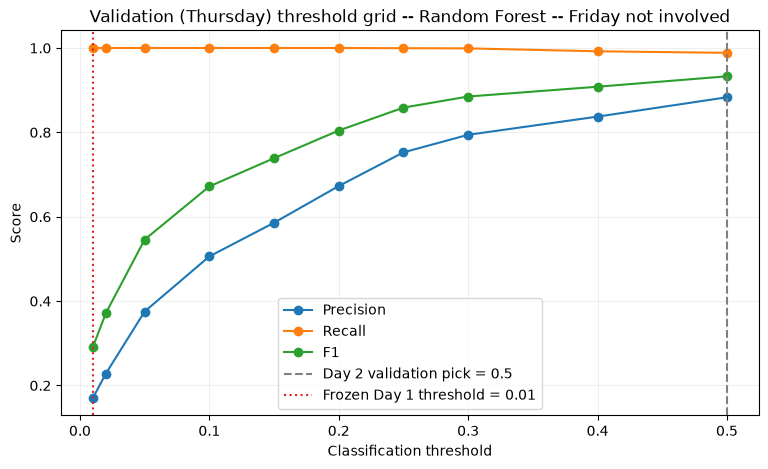

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(rf_validation_selection.grid["threshold"], rf_validation_selection.grid["precision"], marker="o", label="Precision")
plt.plot(rf_validation_selection.grid["threshold"], rf_validation_selection.grid["recall"], marker="o", label="Recall")
plt.plot(rf_validation_selection.grid["threshold"], rf_validation_selection.grid["f1"], marker="o", label="F1")
plt.axvline(rf_validation_selection.threshold, color="gray", linestyle="--", label=f"Day 2 validation pick = {rf_validation_selection.threshold}")
plt.axvline(rf_threshold, color="tab:red", linestyle=":", label=f"Frozen Day 1 threshold = {rf_threshold}")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Validation (Thursday) threshold grid -- Random Forest -- Friday not involved")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 4. Step 3 -- Frozen Friday test

The threshold selected above is now applied to Friday **unchanged**.
This is the proper cross-temporal evaluation; no threshold search
happens against Friday at any point in this notebook.

In [8]:
X_test = test_df[feature_names].fillna(train_medians)
y_test = test_df["label_binary"].astype(int)

test_proba = rf_model.predict_proba(X_test)[:, 1]

frozen_metrics = evaluate_frozen_threshold(y_test, test_proba, rf_threshold)
print(f"Random Forest, frozen at Day 1 threshold={rf_threshold}:")
print(json.dumps(frozen_metrics, indent=2))


Random Forest, frozen at Day 1 threshold=0.01:
{
  "threshold": 0.01,
  "precision": 0.8234700548591569,
  "recall": 0.8818556089097233,
  "f1": 0.8516633533114566,
  "fpr": 0.06445486317417239,
  "fnr": 0.11814439109027677,
  "tn": 360575,
  "fp": 24842,
  "fn": 15525,
  "tp": 115882,
  "roc_auc": 0.9694697874913234,
  "pr_auc": 0.9100762369323754
}


In [9]:
test_pred = (test_proba >= rf_threshold).astype(int)

per_class = None
if "label_multiclass" in test_df.columns:
    per_class = per_class_frozen_results(test_proba, test_pred, test_df["label_multiclass"])
    display(per_class)
else:
    print("label_multiclass not present in test_df -- per-class breakdown skipped.")


,class,samples,predicted_attack,detection_rate,mean_attack_probability,median_attack_probability,max_attack_probability
0,Benign,385417,24842,0.064455,0.004876,0.000000,0.997751
1,DDoS,128014,114299,0.892863,0.177846,0.230000,0.719902
2,PortScan,1956,1261,0.644683,0.117940,0.050000,0.997961
3,Bot,1437,322,0.224078,0.003435,0.000005,0.020000


## 5. Step 4 -- Unseen-attack analysis

In [10]:
if "label_multiclass" in val_split.subtrain_df.columns and "label_multiclass" in test_df.columns:
    unseen_classes = identify_unseen_classes(
        val_split.subtrain_df["label_multiclass"].unique(),
        test_df["label_multiclass"].unique(),
    )
    print("Friday classes absent from the (Monday-Wednesday) sub-train period:")
    print(unseen_classes)
    print()
    print(
        "Note: the deployed Random Forest was trained on the full "
        "Monday-Thursday set, which DOES include DDoS/PortScan/Bot rows "
        "(per the Day 1 project brief). Good Friday performance on these "
        "classes therefore reflects the model having seen the *class* "
        "during training, on *different days* -- not a model that has "
        "never encountered these attack types at all. This distinction "
        "is kept explicit rather than implied."
    )
else:
    print("label_multiclass column not available -- cannot run unseen-attack analysis.")


Friday classes absent from the (Monday-Wednesday) sub-train period:
['Bot', 'DDoS', 'PortScan']

Note: the deployed Random Forest was trained on the full Monday-Thursday set, which DOES include DDoS/PortScan/Bot rows (per the Day 1 project brief). Good Friday performance on these classes therefore reflects the model having seen the *class* during training, on *different days* -- not a model that has never encountered these attack types at all. This distinction is kept explicit rather than implied.


## 6. Step 5 -- Lightweight anomaly detector (IsolationForest)

In [11]:
anomaly_sample = sample_training_data(
    train_df,
    feature_names,
    n_samples=100_000,
    benign_fraction=0.9,
    random_state=42,
)
print(json.dumps(anomaly_sample.summary(), indent=2))


{
  "n_samples": 100000,
  "n_benign": 90000,
  "n_attack": 10000,
  "benign_fraction_requested": 0.9,
  "benign_fraction_actual": 0.9,
  "random_state": 42,
  "n_features": 58
}


In [12]:
anomaly_model = fit_isolation_forest(
    anomaly_sample,
    feature_names,
    contamination=0.05,
    random_state=42,
)
print(json.dumps(anomaly_model.config_summary(), indent=2))


{
  "model_type": "IsolationForest",
  "contamination": 0.05,
  "n_estimators": 100,
  "random_state": 42,
  "n_training_samples": 100000,
  "n_features": 58
}


In [13]:
val_anomaly = anomaly_scores(anomaly_model, val_split.val_df)
test_anomaly = anomaly_scores(anomaly_model, test_df)

# IsolationForest threshold selection -- VALIDATION ONLY, on the anomaly
# detector's own score scale (not the RF's). Small predefined grid;
# frozen before touching Friday.
anomaly_selection = select_threshold_from_validation(
    y_val, val_anomaly, thresholds=DEFAULT_THRESHOLD_GRID
)
print("Selected IsolationForest threshold (validation only):", anomaly_selection.threshold)
print(json.dumps(anomaly_selection.validation_metrics, indent=2))

frozen_anomaly_metrics = evaluate_frozen_threshold(
    y_test, test_anomaly, anomaly_selection.threshold
)
print("\nIsolationForest alone, frozen at its own validation-selected threshold:")
print(json.dumps(frozen_anomaly_metrics, indent=2))


Selected IsolationForest threshold (validation only): 0.15
{
  "threshold": 0.15,
  "precision": 0.01912754860123281,
  "recall": 0.9256539697108765,
  "f1": 0.03748060466974514,
  "fpr": 0.28630307995936566,
  "fnr": 0.07434603028912345,
  "tn": 257838,
  "fp": 103433,
  "fn": 162,
  "tp": 2017
}

IsolationForest alone, frozen at its own validation-selected threshold:
{
  "threshold": 0.15,
  "precision": 0.4416981847355568,
  "recall": 0.7625240664500369,
  "f1": 0.5593743109074111,
  "fpr": 0.32861290498343354,
  "fnr": 0.2374759335499631,
  "tn": 258764,
  "fp": 126653,
  "fn": 31206,
  "tp": 100201,
  "roc_auc": 0.7846164158018528,
  "pr_auc": 0.4483620375280578
}


## 7. Step 6 -- Hybrid detector

In [14]:
hybrid_config = HybridConfig(rf_weight=0.7, anomaly_weight=0.3)

val_hybrid = combine_scores(val_proba, val_anomaly, hybrid_config)
test_hybrid = combine_scores(test_proba, test_anomaly, hybrid_config)

# Hybrid threshold selection -- VALIDATION ONLY, on the hybrid score's
# own scale. Small predefined grid; frozen before touching Friday.
hybrid_selection = select_threshold_from_validation(
    y_val, val_hybrid, thresholds=DEFAULT_THRESHOLD_GRID
)
hybrid_config.threshold = hybrid_selection.threshold
print(json.dumps(hybrid_config.summary(), indent=2))

test_hybrid_pred = hybrid_predict(test_hybrid, hybrid_config.threshold)
frozen_hybrid_metrics = evaluate_frozen_threshold(y_test, test_hybrid, hybrid_config.threshold)
print(json.dumps(frozen_hybrid_metrics, indent=2))


{
  "rf_weight": 0.7,
  "anomaly_weight": 0.3,
  "threshold": 0.5,
  "formula": "hybrid_score = (rf_weight * rf_probability + anomaly_weight * anomaly_score) / (rf_weight + anomaly_weight)"
}
{
  "threshold": 0.5,
  "precision": 0.49375,
  "recall": 0.0006011856293804745,
  "f1": 0.0012009090425410627,
  "fpr": 0.00021016198040044938,
  "fnr": 0.9993988143706195,
  "tn": 385336,
  "fp": 81,
  "fn": 131328,
  "tp": 79,
  "roc_auc": 0.8523945751370673,
  "pr_auc": 0.7314806229755971
}


In [15]:
comparison = pd.DataFrame([
    {"detector": "random_forest", **frozen_metrics},
    {"detector": "isolation_forest", **frozen_anomaly_metrics},
    {"detector": "hybrid", **frozen_hybrid_metrics},
])
comparison


,detector,threshold,precision,recall,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,pr_auc
0,random_forest,0.01,0.823470,0.881856,0.851663,0.064455,0.118144,360575,24842,15525,115882,0.969470,0.910076
1,isolation_forest,0.15,0.441698,0.762524,0.559374,0.328613,0.237476,258764,126653,31206,100201,0.784616,0.448362
2,hybrid,0.50,0.493750,0.000601,0.001201,0.000210,0.999399,385336,81,131328,79,0.852395,0.731481


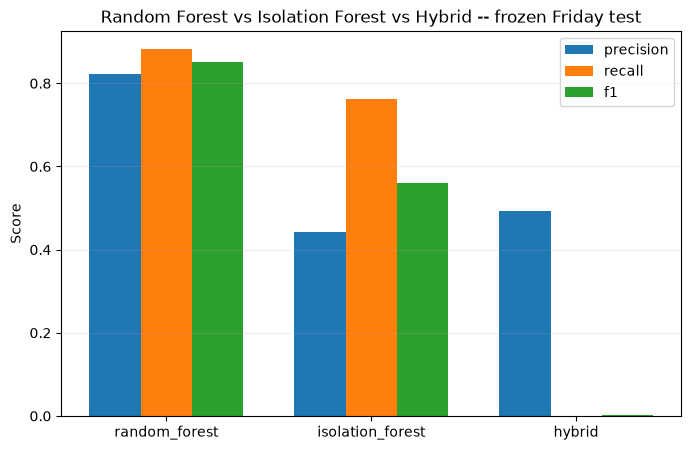

In [16]:
plt.figure(figsize=(8, 5))
metrics_to_plot = ["precision", "recall", "f1"]
x = np.arange(len(comparison))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, comparison[metric], width=width, label=metric)

plt.xticks(x + width, comparison["detector"])
plt.ylabel("Score")
plt.title("Random Forest vs Isolation Forest vs Hybrid -- frozen Friday test")
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.show()


## 8. Step 7 -- Structured, LLM-ready alert (no LLM call)

In [17]:
n_alerts = min(5, int(test_hybrid_pred.sum()))
alert_positions = np.flatnonzero(test_hybrid_pred)[:n_alerts]

sample_alerts = []
for pos in alert_positions:
    sample_alerts.append(
        build_alert(
            row=X_test.iloc[pos],
            feature_names=feature_names,
            rf_probability=float(test_proba[pos]),
            anomaly_score=float(test_anomaly[pos]),
            hybrid_score=float(test_hybrid[pos]),
            rf_threshold=rf_threshold,
            hybrid_threshold=hybrid_config.threshold,
            predicted_label=int(test_hybrid_pred[pos]),
        )
    )

print(json.dumps(sample_alerts[:2], indent=2))


[
  {
    "timestamp": null,
    "predicted_label": 1,
    "rf_attack_probability": 0.9443066009915705,
    "anomaly_score": 0.5999413764545812,
    "hybrid_score": 0.8409970336304737,
    "thresholds_used": {
      "rf_threshold": 0.01,
      "hybrid_threshold": 0.5
    },
    "detector_decisions": {
      "random_forest": true,
      "hybrid": true
    },
    "top_feature_values": {
      "Flow Duration": 63142065.0,
      "Fwd IAT Total": 63100000.0,
      "Flow IAT Max": 32100000.0,
      "Fwd IAT Max": 32100000.0,
      "Idle Max": 32100000.0
    }
  },
  {
    "timestamp": null,
    "predicted_label": 1,
    "rf_attack_probability": 0.9690851405689515,
    "anomaly_score": 0.600917140759339,
    "hybrid_score": 0.8586347406260677,
    "thresholds_used": {
      "rf_threshold": 0.01,
      "hybrid_threshold": 0.5
    },
    "detector_decisions": {
      "random_forest": true,
      "hybrid": true
    },
    "top_feature_values": {
      "Flow Duration": 63147453.0,
      "Fwd IAT 

## 9. Save Day 2 outputs

In [18]:
joblib.dump(anomaly_model.model, DAY2_MODEL_DIR / "isolation_forest.joblib")

day2_metadata = {
    "validation_split": val_split.summary(),
    "random_forest": {
        "day1_frozen_threshold": rf_threshold,
        "day2_validation_selection": rf_validation_selection.summary(),
        "note": (
            "Friday evaluation uses the Day 1 frozen threshold "
            "(RF_DAY1_FROZEN_THRESHOLD), not the Day 2 "
            "validation-selected value above, which is reported "
            "for comparison only."
        ),
    },
    "isolation_forest_threshold_selection": anomaly_selection.summary(),
    "hybrid_threshold_selection": hybrid_selection.summary(),
    "isolation_forest_config": anomaly_model.config_summary(),
    "isolation_forest_sample": anomaly_sample.summary(),
    "hybrid_config": hybrid_config.summary(),
}
(DAY2_MODEL_DIR / "day2_metadata.json").write_text(json.dumps(day2_metadata, indent=2, default=str))

(RESULTS_DIR / "validation_threshold_selection.json").write_text(
    json.dumps(
        {
            "random_forest": {
                "day1_frozen_threshold_used": rf_threshold,
                "day2_validation_selection": rf_validation_selection.summary(),
            },
            "isolation_forest": anomaly_selection.summary(),
            "hybrid": hybrid_selection.summary(),
        },
        indent=2,
        default=str,
    )
)
rf_validation_selection.grid.to_csv(RESULTS_DIR / "validation_threshold_grid_rf.csv", index=False)
anomaly_selection.grid.to_csv(RESULTS_DIR / "validation_threshold_grid_isolation_forest.csv", index=False)
hybrid_selection.grid.to_csv(RESULTS_DIR / "validation_threshold_grid_hybrid.csv", index=False)
(RESULTS_DIR / "frozen_friday_metrics.json").write_text(json.dumps(frozen_metrics, indent=2, default=str))
if per_class is not None:
    per_class.to_csv(RESULTS_DIR / "frozen_friday_per_class.csv", index=False)
(RESULTS_DIR / "isolation_forest_config.json").write_text(
    json.dumps(anomaly_model.config_summary(), indent=2, default=str)
)
comparison.to_csv(RESULTS_DIR / "comparison_table.csv", index=False)
(RESULTS_DIR / "sample_alerts.json").write_text(json.dumps(sample_alerts, indent=2, default=str))

print("Day 2 outputs written to:", RESULTS_DIR)


Day 2 outputs written to: c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\results\day2


## 10. Summary

- Validation split: Monday-Wednesday (sub-train, documented only) /
  Thursday (validation). Friday never touched until Step 4 above.
- **Random Forest**: frozen at Day 1's established threshold
  (`RF_DAY1_FROZEN_THRESHOLD = 0.01`). Day 2's own validation-based pick
  is computed and reported separately for comparison, but is not what
  gets applied to Friday.
- **IsolationForest** and **Hybrid** each get their own threshold,
  independently selected from the Thursday validation split on their own
  score scale (small predefined grid, never tuned on Friday), then frozen
  before Friday evaluation.
- IsolationForest trained on a small (100k-row, ~90% benign) sample of
  the training data -- not the full 1.8M-row set.
- Hybrid = 0.7 * RF probability + 0.3 * normalized anomaly score, a
  transparent weighted average (not a learned ensemble).
- All three detectors are compared on the frozen Friday test in the
  `comparison` table above, **each at its own frozen threshold**.


In [19]:
# ============================================================
# Day 2 Diagnostic: Validation vs Friday Score Distributions
# ============================================================

import numpy as np
import pandas as pd

print("=== SCORE DISTRIBUTION SUMMARY ===")

summary = pd.DataFrame({
    "RF_validation": pd.Series(val_proba).describe(),
    "RF_friday": pd.Series(test_proba).describe(),
    "IF_validation": pd.Series(val_anomaly).describe(),
    "IF_friday": pd.Series(test_anomaly).describe(),
    "Hybrid_validation": pd.Series(val_hybrid).describe(),
    "Hybrid_friday": pd.Series(test_hybrid).describe(),
})

display(summary)

=== SCORE DISTRIBUTION SUMMARY ===


,RF_validation,RF_friday,IF_validation,IF_friday,Hybrid_validation,Hybrid_friday
count,363450.000000,516824.000000,363450.000000,516824.000000,363450.000000,516824.000000
mean,0.008228,0.048143,0.130174,0.194430,0.044812,0.092029
std,0.078880,0.104148,0.148071,0.192691,0.071658,0.116230
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.024901,0.041820,0.007470,0.012553
50%,0.000000,0.000000,0.082886,0.127034,0.026336,0.040712
75%,0.000003,0.010000,0.166104,0.313706,0.054202,0.110221
max,1.000000,0.997961,1.000000,1.000000,0.977815,0.874786


In [20]:
# ============================================================
# Hybrid score distribution by true class
# ============================================================

print("=== HYBRID SCORE BY TRUE CLASS ===")

validation_hybrid_by_class = pd.DataFrame({
    "score": np.asarray(val_hybrid),
    "label": np.asarray(y_val)
})

friday_hybrid_by_class = pd.DataFrame({
    "score": np.asarray(test_hybrid),
    "label": np.asarray(y_test)
})

print("\n--- Validation (Thursday) ---")
display(
    validation_hybrid_by_class
    .groupby("label")["score"]
    .describe()
)

print("\n--- Friday ---")
display(
    friday_hybrid_by_class
    .groupby("label")["score"]
    .describe()
)

=== HYBRID SCORE BY TRUE CLASS ===

--- Validation (Thursday) ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,361271.0,0.040700,0.047975,0.000000,0.007423,0.026047,0.053001,0.874095
1,2179.0,0.726535,0.085738,0.175296,0.744485,0.746558,0.746817,0.977815



--- Friday ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,385417.0,0.049605,0.063186,0.000000,0.007405,0.028969,0.066446,0.874786
1,131407.0,0.216459,0.143741,0.015002,0.053281,0.260762,0.309311,0.745378


In [21]:
# ============================================================
# Why did Friday attack hybrid scores drop?
# Compare RF and Isolation Forest scores for attacks only.
# ============================================================

print("=== ATTACK-ONLY SCORE COMPARISON ===")

val_attack = np.asarray(y_val) == 1
test_attack = np.asarray(y_test) == 1

attack_scores = pd.DataFrame({
    "Validation_RF": pd.Series(
        np.asarray(val_proba)[val_attack]
    ).describe(),

    "Friday_RF": pd.Series(
        np.asarray(test_proba)[test_attack]
    ).describe(),

    "Validation_IF": pd.Series(
        np.asarray(val_anomaly)[val_attack]
    ).describe(),

    "Friday_IF": pd.Series(
        np.asarray(test_anomaly)[test_attack]
    ).describe(),

    "Validation_Hybrid": pd.Series(
        np.asarray(val_hybrid)[val_attack]
    ).describe(),

    "Friday_Hybrid": pd.Series(
        np.asarray(test_hybrid)[test_attack]
    ).describe(),
})

display(attack_scores)

=== ATTACK-ONLY SCORE COMPARISON ===


,Validation_RF,Friday_RF,Validation_IF,Friday_IF,Validation_Hybrid,Friday_Hybrid
count,2179.000000,131407.000000,2179.000000,131407.000000,2179.000000,131407.000000
mean,0.960216,0.175047,0.181280,0.313087,0.726535,0.216459
std,0.110493,0.136842,0.098095,0.170669,0.085738,0.143741
min,0.231817,0.000000,0.043415,0.026673,0.175296,0.015002
25%,0.995157,0.010003,0.158473,0.151551,0.744485,0.053281
50%,0.996081,0.230000,0.164339,0.336697,0.746558,0.260762
75%,0.996357,0.270000,0.165403,0.448244,0.746817,0.309311
max,1.000000,0.997961,0.972715,0.796510,0.977815,0.745378


In [22]:
# ============================================================
# Day 2 Diagnostic: Random Forest Feature Importance
# ============================================================

import pandas as pd
import joblib
import json
from pathlib import Path

# Paths
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "day1"
    / "random_forest_baseline.joblib"
)

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "day1"
    / "split_metadata.json"
)

# Load model and metadata
rf_model = joblib.load(MODEL_PATH)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

feature_names = metadata["feature_names"]

# Build feature-importance table
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("=== DAY 2 RANDOM FOREST FEATURE IMPORTANCE ===")

display(feature_importance.head(20))

=== DAY 2 RANDOM FOREST FEATURE IMPORTANCE ===


,feature,importance
0,Packet Length Max,0.100126
1,Bwd Packet Length Std,0.097290
2,Packet Length Variance,0.072273
3,Packet Length Std,0.061462
4,Packet Length Mean,0.061202
5,Bwd Packet Length Mean,0.055361
6,Bwd Packet Length Max,0.053883
7,Flow Packets/s,0.050631
8,Avg Packet Size,0.034910
9,Fwd IAT Max,0.032136


In [23]:
# ============================================================
# Day 2 Diagnostic: Top Feature Drift
# Training (Mon-Thu) vs Frozen Friday
# ============================================================

import numpy as np
import pandas as pd

# Top 20 RF features
top_features = feature_importance.head(20)["feature"].tolist()

# Training and Friday data
train_features = train_df[top_features].copy()
friday_features = test_df[top_features].copy()

# Compare distributions
drift_rows = []

for feature in top_features:
    train_col = pd.to_numeric(
        train_features[feature], errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    friday_col = pd.to_numeric(
        friday_features[feature], errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    # Basic distribution statistics
    train_median = train_col.median()
    friday_median = friday_col.median()

    train_mean = train_col.mean()
    friday_mean = friday_col.mean()

    # Median shift
    if train_median != 0:
        median_shift_pct = (
            (friday_median - train_median)
            / abs(train_median)
        ) * 100
    else:
        median_shift_pct = np.nan

    # Mean shift
    if train_mean != 0:
        mean_shift_pct = (
            (friday_mean - train_mean)
            / abs(train_mean)
        ) * 100
    else:
        mean_shift_pct = np.nan

    drift_rows.append({
        "feature": feature,
        "RF_importance": feature_importance.loc[
            feature_importance["feature"] == feature,
            "importance"
        ].iloc[0],
        "train_mean": train_mean,
        "friday_mean": friday_mean,
        "mean_shift_%": mean_shift_pct,
        "train_median": train_median,
        "friday_median": friday_median,
        "median_shift_%": median_shift_pct,
    })

drift_report = (
    pd.DataFrame(drift_rows)
    .sort_values("RF_importance", ascending=False)
    .reset_index(drop=True)
)

print("=== TOP-20 FEATURE DRIFT: TRAINING vs FRIDAY ===")

display(drift_report)

=== TOP-20 FEATURE DRIFT: TRAINING vs FRIDAY ===


,feature,RF_importance,train_mean,friday_mean,mean_shift_%,train_median,friday_median,median_shift_%
0,Packet Length Max,0.100126,1.007442e+03,1.681882e+03,66.945773,116.000000,114.000000,-1.724138
1,Bwd Packet Length Std,0.097290,3.519789e+02,6.127468e+02,74.086227,0.000000,0.000000,NaN
2,Packet Length Variance,0.072273,4.009101e+05,1.265576e+06,215.675705,1408.333374,1387.199951,-1.500598
3,Packet Length Std,0.061462,3.026393e+02,5.548058e+02,83.322426,37.527767,37.245132,-0.753135
4,Packet Length Mean,0.061202,1.842182e+02,2.873053e+02,55.959217,68.666664,68.199997,-0.679612
5,Bwd Packet Length Mean,0.055361,3.382474e+02,4.899367e+02,44.845669,102.000000,94.000000,-7.843138
6,Bwd Packet Length Max,0.053883,9.544975e+02,1.441255e+03,50.996211,112.000000,102.000000,-8.928571
7,Flow Packets/s,0.050631,2.102460e+04,1.838122e+04,-12.572787,64.904509,33.145509,-48.931886
8,Avg Packet Size,0.034910,2.042300e+02,3.219698e+02,57.650608,88.000000,88.000000,0.000000
9,Fwd IAT Max,0.032136,1.184021e+07,8.302909e+06,-29.875299,155.000000,778.000000,401.935484
